<a href="https://colab.research.google.com/github/etaiadmi/BaltimoreCountyLandClassification/blob/main/ModelCreation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q geoai-py leafmap rasterio geopandas segmentation-models-pytorch rio-cogeo rioxarray requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 

In [5]:
import requests
import os
import glob
import leafmap
import rasterio
import numpy as np
import geoai
import rioxarray
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

In [ ]:

# Create the main folder to store all LULC tiles
os.makedirs("/content/drive/MyDrive/lulc_tiles", exist_ok=True)

# Baltimore County bounding box in regular lat/lon coordinates
# These four numbers define the rectangle we want to download
# WEST and EAST are longitude, SOUTH and NORTH are latitude
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72

# How big each tile is in degrees
# 0.05 degrees is roughly 5km x 5km
# Smaller = more tiles but each one downloads faster
TILE_SIZE = 0.05

# These are the REST service URLs for each time period of the LULC data
# T3 = time period 3 = 2021/2022 (most recent)
# T1 = time period 1 = 2013/2014 (historical, for comparison)
# We download both so we can compare land cover change over ~8 years
URL_2022 = "https://cicgis.org/arcgis/rest/services/Imagery/CBW_LULC_T3_2024_Edition_2/ImageServer/exportImage"
URL_2013 = "https://cicgis.org/arcgis/rest/services/Imagery/CBW_lulc_t1_2024_Edition_publish/ImageServer/exportImage"
# Calculate how many tiles we need in each direction
# For example if the county spans 0.43 degrees west-to-east
# and each tile is 0.05 degrees wide, we need 8 tiles across
x_steps = int((EAST - WEST) / TILE_SIZE)   # number of columns
y_steps = int((NORTH - SOUTH) / TILE_SIZE) # number of rows

print(f"Grid size: {x_steps} columns x {y_steps} rows = {x_steps * y_steps} total tiles per year")

# Loop through both time periods
for year, url in [("2022", URL_2022), ("2013", URL_2013)]:

    # Create a separate subfolder for each year so files don't mix
    folder = f"lulc_tiles/{year}"
    os.makedirs(folder, exist_ok=True)

    success = 0  # count tiles that downloaded correctly
    fail = 0     # count tiles that failed
    count = 0    # overall tile counter for progress display

    print(f"\n--- Downloading {year} LULC ---")

    # Loop through every tile in the grid
    for xi in range(x_steps):       # xi = column index (west to east)
        for yi in range(y_steps):   # yi = row index (south to north)

            # Calculate the exact lat/lon boundaries for this specific tile
            w = WEST + xi * TILE_SIZE       # left edge of tile
            e = w + TILE_SIZE               # right edge of tile
            s = SOUTH + yi * TILE_SIZE      # bottom edge of tile
            n = s + TILE_SIZE               # top edge of tile

            # Name the output file using the grid position
            # e.g. tile_003_007.tif means column 3, row 7
            fname = f"{folder}/tile_{xi:03d}_{yi:03d}.tif"

            # Skip this tile if we already downloaded it
            # This way if the script crashes halfway through,
            # we can re-run it and it picks up where it left off
            if os.path.exists(fname):
                print(f"  Skipping tile_{xi}_{yi} (already exists)")
                continue

            count += 1

            # Build the request parameters to send to the server
            # This tells the server exactly what area and format we want
            params = {
                "bbox": f"{w},{s},{e},{n}",  # bounding box of the tile
                "bboxSR": 4326,              # 4326 means our bbox is in lat/lon
                "size": "2048,2048",         # output image size in pixels
                "imageSR": 4326,             # output file should also be in lat/lon
                "format": "tiff",            # save as GeoTIFF (standard raster format)
                "pixelType": "U8",           # pixel values are 0-255 integers (class IDs)
                "f": "image"                 # return raw image bytes, not JSON metadata
            }

            try:
                # Send the request to the server
                # stream=True means we download the file in chunks instead of all at once
                # timeout=120 means give up if no response after 2 minutes
                r = requests.get(url, params=params, stream=True, timeout=120)

                if r.status_code == 200:
                    # 200 means success - write the image data to disk chunk by chunk
                    with open(fname, "wb") as f:
                        for chunk in r.iter_content(8192):  # 8192 bytes at a time
                            f.write(chunk)
                    success += 1
                    print(f"  [{count}] tile_{xi}_{yi} ✓")

                else:
                    # Any other status code means something went wrong on the server
                    # 500 usually means the tile is outside the coverage area (fine to ignore)
                    fail += 1
                    print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code})")

            except Exception as e:
                # This catches network errors like timeouts or connection drops
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} error: {e}")

    print(f"  Done: {success} downloaded, {fail} failed (500s are normal at county edges)")

print("\nAll done!")
print("Your files are in lulc_tiles/2022/ and lulc_tiles/2013/")
print("Each .tif file is a grid of numbers where each number = a land cover class")
print("e.g. forest=1, impervious road=2, water=3, etc.")



Grid size: 8 columns x 10 rows = 80 total tiles per year

--- Downloading 2022 LULC ---
  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [

__STEP 2: Download Maryland Aerial Imagery (3-inch, 5-band)__

In [ ]:
# @title
os.makedirs("/content/drive/MyDrive/imagery_tiles", exist_ok=True)

# Maryland iMAP 3-inch aerial imagery REST service
# This is the same ExportImage approach as the LULC download
IMAGERY_URL = "https://mdgeodata.md.gov/imagery/rest/services/ThreeInch/MD_ThreeInchImagery/ImageServer/exportImage"

# IMPORTANT: Use the exact same bounding box and tile size as the LULC download
# This guarantees every imagery tile has a matching LULC tile with the same coverage
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72
TILE_SIZE = 0.05

x_steps = int((EAST - WEST) / TILE_SIZE)
y_steps = int((NORTH - SOUTH) / TILE_SIZE)

print(f"Downloading {x_steps * y_steps} imagery tiles...")
print("This will take longer than the LULC download because imagery files are bigger\n")

success = 0
fail = 0
count = 0

for xi in range(x_steps):
    for yi in range(y_steps):

        w = WEST + xi * TILE_SIZE
        e = w + TILE_SIZE
        s = SOUTH + yi * TILE_SIZE
        n = s + TILE_SIZE

        # Name matches LULC tiles exactly — tile_004_004 imagery lines up with
        # tile_004_004 LULC, making the pairing step trivial later
        fname = f"imagery_tiles/tile_{xi:03d}_{yi:03d}.tif"

        if os.path.exists(fname) and os.path.getsize(fname) > 1000:
            print(f"  Skipping tile_{xi}_{yi} (already exists)")
            continue

        count += 1

        params = {
            "bbox": f"{w},{s},{e},{n}",
            "bboxSR": 4326,       # coordinates are in lat/lon
            "size": "2048,2048",  # same pixel dimensions as LULC tiles
            "imageSR": 4326,      # output in lat/lon
            "format": "tiff",
            "pixelType": "U8",
            "bandIds": "0,1,2",
            "f": "image"
        }

        try:
            r = requests.get(IMAGERY_URL, params=params, stream=True, timeout=120)

            if r.status_code == 200 and len(r.content) > 1000:
                with open(fname, "wb") as f:
                    for chunk in r.iter_content(8192):
                        f.write(chunk)
                success += 1
                print(f"  [{count}] tile_{xi}_{yi} ✓")
            else:
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code})")

        except Exception as e:
            fail += 1
            print(f"  [{count}] tile_{xi}_{yi} error: {e}")

print(f"\nDone: {success} downloaded, {fail} failed")

This will take longer than the LULC download because imagery files are bigger

  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [52] tile_

In [25]:

dir = "/content/drive/MyDrive/imagery_tiles_2013"
os.makedirs(dir, exist_ok=True)

# Maryland iMAP 3-inch aerial imagery REST service
# This is the same ExportImage approach as the LULC download
IMAGERY_URL = "https://mdgeodata.md.gov/imagery/rest/services/NAIP/NAIPImagery2013/ImageServer/exportImage"

# IMPORTANT: Use the exact same bounding box and tile size as the LULC download
# This guarantees every imagery tile has a matching LULC tile with the same coverage
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72
TILE_SIZE = 0.05

x_steps = int((EAST - WEST) / TILE_SIZE)
y_steps = int((NORTH - SOUTH) / TILE_SIZE)

print(f"Downloading {x_steps * y_steps} imagery tiles...")
print("This will take longer than the LULC download because imagery files are bigger\n")

success = 0
fail = 0
count = 0

for xi in range(x_steps):
    for yi in range(y_steps):

        w = WEST + xi * TILE_SIZE
        e = w + TILE_SIZE
        s = SOUTH + yi * TILE_SIZE
        n = s + TILE_SIZE

        # Name matches LULC tiles exactly — tile_004_004 imagery lines up with
        # tile_004_004 LULC, making the pairing step trivial later
        fname = f"{dir}/tile_{xi:03d}_{yi:03d}.tif"

        if os.path.exists(fname) and os.path.getsize(fname) > 1000:
            print(f"  Skipping tile_{xi}_{yi} (already exists)")
            continue

        count += 1

        params = {
            "bbox": f"{w},{s},{e},{n}",
            "bboxSR": 4326,       # coordinates are in lat/lon
            "size": "2048,2048",  # same pixel dimensions as LULC tiles
            "imageSR": 4326,      # output in lat/lon
            "format": "tiff",
            "pixelType": "U8",
            "bandIds": "0,1,2",
            "f": "image"
        }

        try:
            r = requests.get(IMAGERY_URL, params=params, stream=True, timeout=120)

            if r.status_code == 200 and len(r.content) > 1000:
                with open(fname, "wb") as f:
                    for chunk in r.iter_content(8192):
                        f.write(chunk)
                success += 1
                print(f"  [{count}] tile_{xi}_{yi} ✓")
            else:
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code})")

        except Exception as e:
            fail += 1
            print(f"  [{count}] tile_{xi}_{yi} error: {e}")

print(f"\nDone: {success} downloaded, {fail} failed")

This will take longer than the LULC download because imagery files are bigger

  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [52] tile_

In [ ]:


# --- CONFIGURATION ---
input_folder = '/content/drive/MyDrive/lulc_tiles/2022'
output_folder = '/content/drive/MyDrive/lulc_tiles/2022_reclassed'

# Ensure output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

reclass_map = {
    # Water (Now 0)
    10: 0, 11: 0, 12: 0, 13: 0, 14: 0,

    # Developed (Now 1)
    20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1,
    30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1,

    # Natural
    15: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 2, 45: 2, 46: 2,
    50: 2, 51: 2, 52: 2, 53: 2, 54: 2, 55: 2,
    60: 2, 61: 2, 62: 2, 63: 2, 64: 2, 65: 2,
    70: 2, 71: 2, 72: 2, 73: 2, 74: 2, 75: 2,

    # Agriculture (Now 3)
    80: 3, 81: 3, 82: 3, 83: 3, 84: 3, 85: 3, 86: 3
}

# Pre-calculate a lookup array for extreme speed (works for values 0-255)
lookup = np.zeros(256, dtype=np.uint8)
for old_val, new_val in reclass_map.items():
    lookup[old_val] = new_val

# --- PROCESSING ---
for filename in os.listdir(input_folder):
    if filename.endswith(".tif") or filename.endswith(".tiff"):
        in_path = os.path.join(input_folder, filename)
        out_path = os.path.join(output_folder, f"{filename}")

        print(f"Processing: {filename}...")

        with rasterio.open(in_path) as src:
            meta = src.meta.copy()
            meta.update({
                'dtype': 'uint8',
                'nodata': 0,
                'compress': 'lzw',
                'count': 1
            })

            with rasterio.open(out_path, 'w', **meta) as dst:
                # Process in blocks (windows) to save RAM
                for ij, window in src.block_windows():
                    # Read the chunk
                    block = src.read(1, window=window)

                    # Apply reclassification using the lookup array
                    # This is much faster than a python loop or .get()
                    reclassed_block = lookup[block]

                    # Write the chunk
                    dst.write(reclassed_block, 1, window=window)

print("Batch processing complete!")

Processing: tile_002_006.tif...
Processing: tile_003_000.tif...
Processing: tile_005_005.tif...
Processing: tile_007_009.tif...
Processing: tile_002_001.tif...
Processing: tile_001_007.tif...
Processing: tile_004_008.tif...
Processing: tile_007_006.tif...
Processing: tile_000_002.tif...
Processing: tile_003_007.tif...
Processing: tile_005_002.tif...
Processing: tile_003_001.tif...
Processing: tile_001_003.tif...
Processing: tile_001_001.tif...
Processing: tile_002_005.tif...
Processing: tile_006_004.tif...
Processing: tile_005_004.tif...
Processing: tile_000_008.tif...
Processing: tile_007_004.tif...
Processing: tile_004_000.tif...
Processing: tile_004_004.tif...
Processing: tile_003_008.tif...
Processing: tile_002_009.tif...
Processing: tile_005_007.tif...
Processing: tile_006_000.tif...
Processing: tile_001_004.tif...
Processing: tile_004_003.tif...
Processing: tile_002_007.tif...
Processing: tile_000_000.tif...
Processing: tile_003_003.tif...
Processing: tile_002_003.tif...
Processi

In [11]:


# Define your directories and mask
dir_paths = ["/content/drive/MyDrive/imagery_tiles",
             "/content/drive/MyDrive/lulc_tiles/2013_reclassed",
             "/content/drive/MyDrive/lulc_tiles/2022_reclassed"]
geojson_mask = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"

for input_dir in dir_paths:
  output_dir = f"{input_dir}_clipped"
  os.makedirs(output_dir, exist_ok=True)

  # Find all TIFF files in the input directory
  tif_files = glob.glob(os.path.join(input_dir, "*.tif"))

  print(f"Found {len(tif_files)} TIFFs. Starting clipping process...")

  for tif in tif_files:
      filename = os.path.basename(tif)
      out_path = os.path.join(output_dir, filename)

      try:
          # Clip the individual TIFF
          leafmap.clip_image(
              image=tif,
              mask=geojson_mask,
              output=out_path
          )
          print(f"Successfully clipped: {filename}")

      except Exception as e:
          # If the TIFF doesn't intersect the GeoJSON, skip it
          print(e)

Found 80 TIFFs. Starting clipping process...


Reading input: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_003.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_003.tif


Successfully clipped: tile_000_003.tif


Reading input: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_004.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_004.tif


Successfully clipped: tile_000_004.tif


...

Successfully clipped: tile_000_009.tif


Reading input: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_003_004.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_003_004.tif


Successfully clipped: tile_003_004.tif


Reading input: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_005_008.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_005_008.tif


Successfully clipped: tile_005_008.tif


In [23]:

leafmap.merge_rasters("/content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped", output="/content/drive/MyDrive/predicted_county/baltimore_full_lulc_2023_clipped.tif")

Merging 80 rasters into 'full_landcover_predicted_2023.tif'...
Raster merge completed successfully: full_landcover_predicted_2023.tif


In [ ]:

leafmap.merge_rasters("/content/drive/MyDrive/lulc_tiles/2013_reclassed_clipped", output="/content/drive/MyDrive/predicted_county/baltimore_full_lulc_2013_clipped.tif")

In [5]:


# Use the directories we created in the previous steps
imagery_dir = "/content/drive/MyDrive/imagery_tiles_clipped"
mask_dir = "/content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped"
out_folder = "/content/drive/MyDrive/baltimore_training_data"

# geoai uses 'export_geotiff_tiles' to create smaller training chips (e.g., 512x512)
# from your larger 2048x2048 tiles.
for img_file in os.listdir(imagery_dir):
    if img_file.endswith(".tif"):
        tile_id = img_file.replace(".tif", "")
        img_path = os.path.join(imagery_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file) # Names match exactly

        # Create 512x512 chips for the AI model
        geoai.export_geotiff_tiles(
            in_raster=img_path,
            out_folder=out_folder,
            in_class_data=mask_path,
            tile_size=512,
            stride=384, # 50% overlap for better training
        )

Generated: 25, With features: 18: 100%|██████████| 25/25 [00:02<00:00,  9.74it/s]


In [13]:
# Updated for Baltimore Landcover Training
# Use the directories we created in the previous steps
imagery_dir = "/content/drive/MyDrive/imagery_tiles"
mask_dir = "/content/drive/MyDrive/lulc_tiles"
out_folder = "/content/drive/MyDrive/baltimore_training_data"

geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/baltimore_models_2",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=4,
    batch_size=16,
    num_epochs=300,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True
  )

In [14]:
previous_model = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_2/best_model.pth"
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/baltimore_models_2",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    checkpoint_path=previous_model,
    num_channels=3,
    num_classes=4,
    batch_size=16,
    num_epochs=30,
    learning_rate=0.0001,
    val_split=0.2,
    verbose=True
  )

In [15]:
test_tile = "/content/drive/MyDrive/imagery_tiles/tile_000_005.tif" # Pick a tile to test
output_mask = "/content/drive/MyDrive/prediction_000_005.tif"

geoai.semantic_segmentation(
    input_path=test_tile,
    output_path=output_mask,
    model_path=f"{out_folder}/baltimore_models_2/best_model.pth",
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256
)

64it [00:01, 32.14it/s]


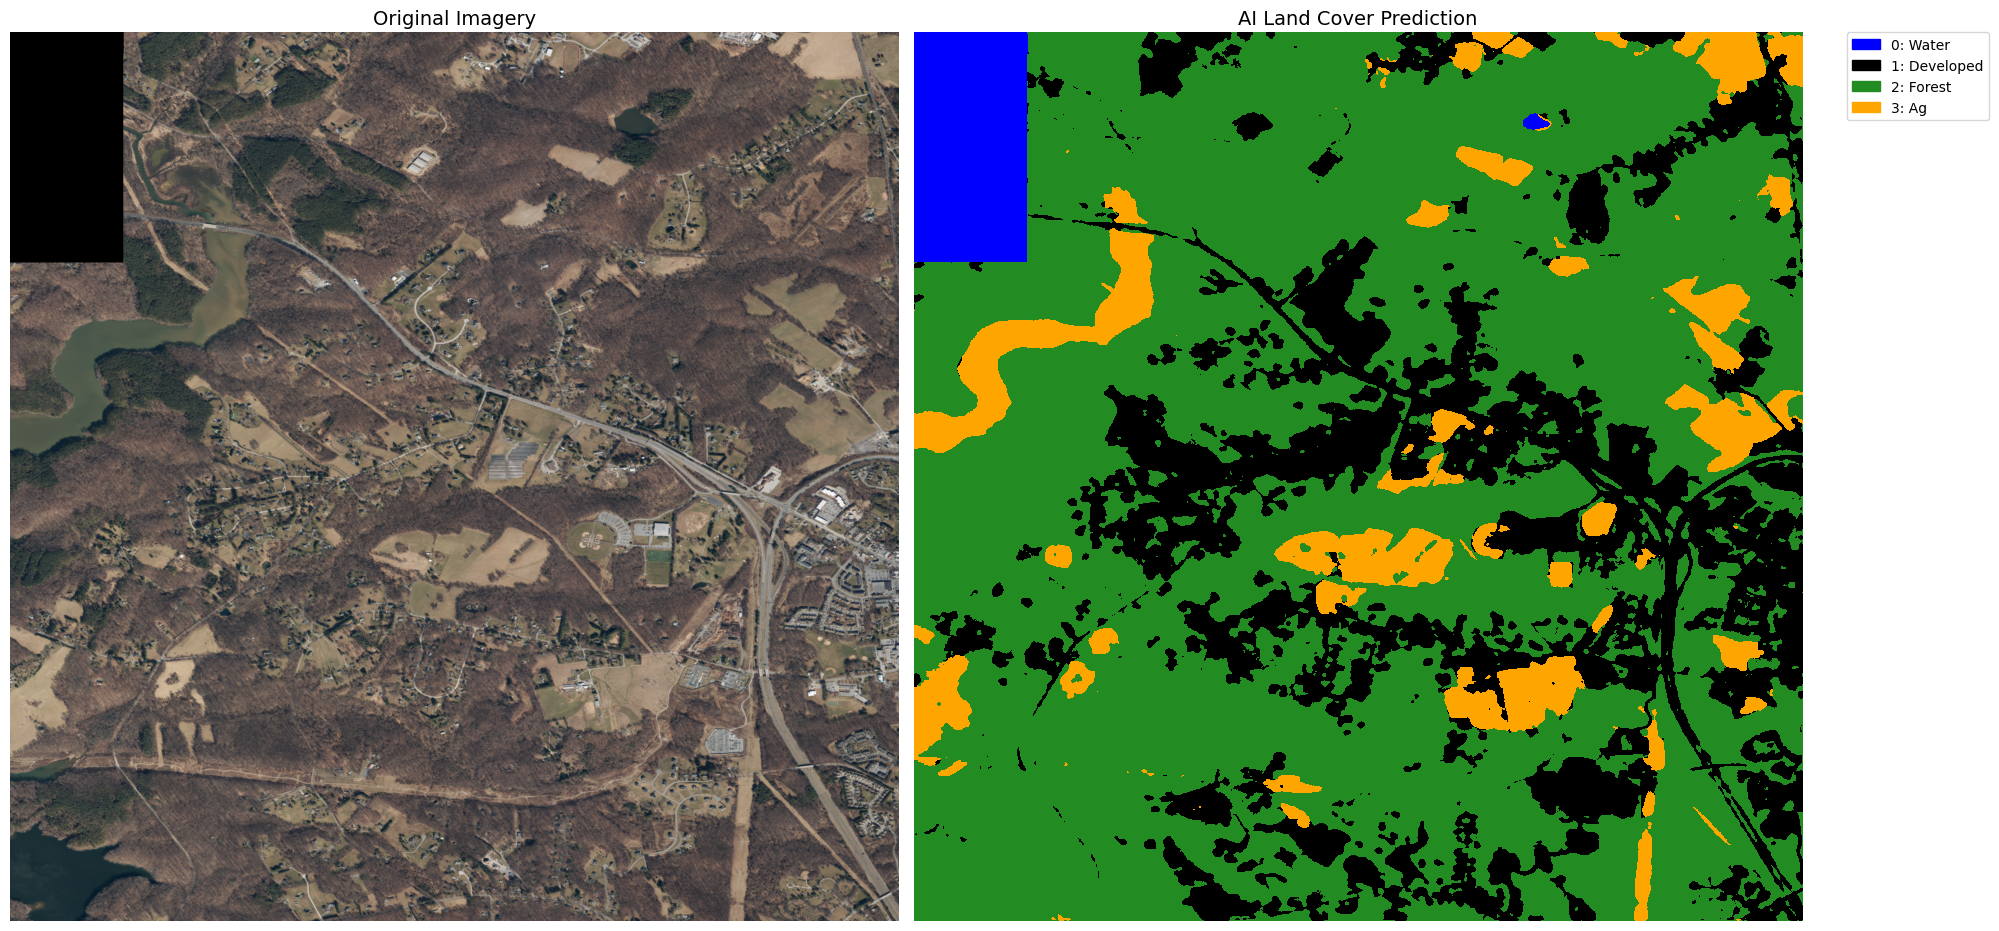

Unique IDs found in this prediction: [0 1 2 3]


In [16]:


# 1. Setup paths

# 2. Define the Color Map and Boundaries
# Updated to 5 classes to account for 0:Background/Unlabeled
osm_colors = ["blue", "black", "forestgreen", "orange"]
osm_labels = ["Water", "Developed", "Forest", "Ag"]
custom_cmap = ListedColormap(osm_colors)

# Create boundaries: [0, 1) is black, [1, 2) is blue, etc.
bounds = [0, 1, 2, 3, 4]
norm = BoundaryNorm(bounds, custom_cmap.N)

# 3. Load the data
img = rioxarray.open_rasterio(test_tile)
pred = rioxarray.open_rasterio(output_mask).squeeze()

# 4. Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# --- Plot Imagery ---
img_display = img.transpose("y", "x", "band")
if img_display.max() > 1:
    img_display = img_display / 255.0

ax1.imshow(img_display)
ax1.set_title(f"Original Imagery", fontsize=14)
ax1.axis('off')

# --- Plot Prediction ---
# Use 'norm' instead of vmin/vmax to fix the color stretching
im2 = ax2.imshow(pred, cmap=custom_cmap, norm=norm, interpolation='nearest')
ax2.set_title("AI Land Cover Prediction", fontsize=14)
ax2.axis('off')

# 5. Add Legend (Dynamically linked to osm_labels)
legend_patches = [
    mpatches.Patch(color=osm_colors[i], label=f"{i}: {osm_labels[i]}")
    for i in range(len(osm_labels))
]
ax2.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# Quick Debug check
print("Unique IDs found in this prediction:", np.unique(pred.values))

In [20]:
# Setup directories
output_dir = "/content/drive/MyDrive/prediction_results_2023"
os.makedirs(output_dir, exist_ok=True)
model_path = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_2/best_model.pth"
# Run batch inference
geoai.semantic_segmentation_batch(
    input_dir=imagery_dir,
    output_dir=output_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256,
    batch_size=4
)

64it [00:01, 32.00it/s]
64it [00:02, 31.35it/s]
64it [00:01, 36.04it/s]
64it [00:01, 34.92it/s]
64it [00:01, 34.90it/s]
64it [00:01, 34.29it/s]
64it [00:02, 31.88it/s]
64it [00:01, 33.92it/s]
64it [00:01, 35.91it/s]
64it [00:01, 37.60it/s]
64it [00:01, 34.45it/s]
64it [00:01, 32.55it/s]
64it [00:02, 31.68it/s]
64it [00:01, 35.51it/s]
64it [00:01, 34.99it/s]
64it [00:01, 32.78it/s]
64it [00:02, 31.79it/s]
64it [00:01, 34.58it/s]
64it [00:01, 34.64it/s]
64it [00:02, 30.55it/s]
64it [00:01, 34.96it/s]
64it [00:02, 31.48it/s]
64it [00:01, 33.68it/s]
64it [00:02, 30.66it/s]
64it [00:01, 35.63it/s]
64it [00:01, 34.69it/s]
64it [00:02, 31.50it/s]
64it [00:01, 35.54it/s]
64it [00:01, 35.71it/s]
64it [00:01, 34.82it/s]
64it [00:01, 35.93it/s]
64it [00:01, 32.28it/s]
64it [00:02, 28.15it/s]
64it [00:01, 35.48it/s]
64it [00:01, 34.91it/s]
64it [00:01, 34.92it/s]
64it [00:02, 31.52it/s]
64it [00:01, 35.14it/s]
64it [00:01, 35.27it/s]
64it [00:01, 35.56it/s]
64it [00:01, 34.94it/s]
64it [00:02, 31.

In [36]:

input_dir = "/content/drive/MyDrive/prediction_results_2023"

output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023.tif"
leafmap.merge_rasters(input_dir, output=output_image)

Merging 80 rasters into '/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023.tif'...
Raster merge completed successfully: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023.tif


In [37]:

input_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023.tif"
geojson_mask = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif"

leafmap.clip_image(
    image=input_image,
    mask=geojson_mask,
    output=output_image
)

Reading input: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif


In [26]:
# Setup directories
output_dir = "/content/drive/MyDrive/prediction_results_2013"
imagery_dir = "/content/drive/MyDrive/imagery_tiles_2013"
os.makedirs(output_dir, exist_ok=True)
model_path = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_2/best_model.pth"
# Run batch inference
geoai.semantic_segmentation_batch(
    input_dir=imagery_dir,
    output_dir=output_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256,
    batch_size=4
)

64it [00:02, 31.79it/s]
64it [00:01, 37.01it/s]
64it [00:01, 37.03it/s]
64it [00:01, 36.35it/s]
64it [00:01, 36.67it/s]
64it [00:01, 32.84it/s]
64it [00:01, 34.96it/s]
64it [00:01, 36.22it/s]
64it [00:01, 36.26it/s]
64it [00:01, 36.31it/s]
64it [00:01, 34.90it/s]
64it [00:01, 32.71it/s]
64it [00:01, 36.38it/s]
64it [00:01, 36.60it/s]
64it [00:01, 36.32it/s]
64it [00:01, 36.08it/s]
64it [00:01, 32.56it/s]
64it [00:02, 23.55it/s]
64it [00:01, 34.51it/s]
64it [00:01, 36.34it/s]
64it [00:02, 23.38it/s]
64it [00:02, 30.60it/s]
64it [00:01, 36.70it/s]
64it [00:01, 36.68it/s]
64it [00:01, 35.85it/s]
64it [00:01, 33.34it/s]
64it [00:01, 36.73it/s]
64it [00:01, 36.37it/s]
64it [00:01, 36.37it/s]
64it [00:01, 36.74it/s]
64it [00:01, 33.79it/s]
64it [00:01, 33.58it/s]
64it [00:01, 36.55it/s]
64it [00:01, 36.64it/s]
64it [00:01, 36.87it/s]
64it [00:01, 33.50it/s]
64it [00:01, 33.41it/s]
64it [00:01, 36.62it/s]
64it [00:01, 37.03it/s]
64it [00:01, 35.67it/s]
64it [00:01, 36.24it/s]
64it [00:01, 33.

In [30]:
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif"
input_dir = "/content/drive/MyDrive/prediction_results_2013"
leafmap.merge_rasters(input_dir, output=output_image)

Merging 80 rasters into '/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif'...
Raster merge completed successfully: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif


In [31]:

input_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif"
geojson_mask = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif"

leafmap.clip_image(
    image=input_image,
    mask=geojson_mask,
    output=output_image
)

Reading input: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif


In [ ]:

input_dir = "/content/drive/MyDrive/imagery_tiles_2013"
output_dir = "/content/drive/MyDrive/prediction_results_2013"
model_path = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_1/best_model.pth"

# Run batch inference
geoai.semantic_segmentation_batch(
    input_dir=input_dir,
    output_dir=output_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256,
    batch_size=4
)

64it [00:02, 24.93it/s]
64it [00:03, 18.62it/s]
64it [00:01, 35.68it/s]
64it [00:01, 36.33it/s]
64it [00:01, 35.69it/s]
64it [00:01, 36.35it/s]
64it [00:01, 33.49it/s]
64it [00:02, 26.84it/s]
64it [00:02, 25.46it/s]
64it [00:01, 33.27it/s]
64it [00:01, 35.48it/s]
64it [00:01, 36.44it/s]
64it [00:01, 35.51it/s]
64it [00:01, 32.82it/s]
64it [00:02, 29.00it/s]
64it [00:02, 25.04it/s]
64it [00:02, 24.66it/s]
64it [00:01, 35.60it/s]
64it [00:01, 35.96it/s]
64it [00:01, 35.37it/s]
64it [00:01, 32.80it/s]
64it [00:02, 30.60it/s]
64it [00:02, 24.29it/s]
64it [00:02, 24.32it/s]
64it [00:01, 35.96it/s]
64it [00:01, 35.52it/s]
64it [00:01, 35.79it/s]
64it [00:01, 35.25it/s]
64it [00:01, 32.59it/s]
64it [00:02, 24.91it/s]
64it [00:02, 24.19it/s]
64it [00:01, 35.43it/s]
64it [00:01, 35.79it/s]
64it [00:01, 35.74it/s]
64it [00:01, 36.37it/s]
64it [00:02, 27.97it/s]
64it [00:02, 27.17it/s]
64it [00:02, 23.87it/s]
64it [00:01, 35.23it/s]
64it [00:01, 35.83it/s]
64it [00:01, 35.90it/s]
64it [00:01, 35.

In [15]:

leafmap.merge_rasters("prediction_results_2013", output="predicted_county/baltimore_full_landcover_2013.tif")

Merging 80 rasters into 'predicted_county/baltimore_full_landcover_2013.tif'...


RuntimeError: Raster merge failed. Please check your inputs and parameters.

Calculate Change Map and Statistics for AI Model

In [3]:
# Load both combined tiffs

pred_t1 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif").squeeze()
pred_t2 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif").squeeze()

# Force pred_t2 to match the exact grid of pred_t1
pred_t2 = pred_t2.rio.reproject_match(pred_t1)

# Create a transition raster
# New value = (Time1 * 10) + Time2
change_map = (pred_t1 * 10) + pred_t2

# Now you can filter for specific transitions
# Let's find "Deforestation" (Forest [3] -> Developed [1])

# Save the result to your Drive
change_map.rio.to_raster("land_cover_transitions.tif")

In [4]:
# Load and immediately downsample by a factor of 5
# This turns a 10000x10000 image into 2000x2000
pred_t1_small = pred_t1.rio.reproject(pred_t1.rio.crs, shape=(pred_t1.rio.height // 10, pred_t1.rio.width // 10))
pred_t2_small = pred_t2.rio.reproject(pred_t2.rio.crs, shape=(pred_t2.rio.height // 10, pred_t2.rio.width // 10))

change_map_small = (pred_t1_small * 10) + pred_t2_small
# Now plot change_map_small

In [8]:

geojson_path = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"
change_map = change_map.rio.reproject("EPSG:32618")
# 1. Load your GeoJSON
regions = gpd.read_file(geojson_path)

# 2. CRITICAL: Ensure the GeoJSON and the Raster share the exact same CRS
regions = regions.to_crs(change_map.rio.crs)

# 3. Separate the urban and rural geometries based on LAND_TYPE
urban_geoms = regions[regions['LAND_TYPE'] == 0].geometry
rural_geoms = regions[regions['LAND_TYPE'] == 1].geometry

# 4. Helper function to clip and count pixels
def count_transitions(raster, geoms, transition_codes):
    if geoms.empty:
        return {code: 0 for code in transition_codes}

    # Clip the raster to the geometries. drop=True removes extra empty space.
    clipped_raster = raster.rio.clip(geoms, raster.rio.crs, drop=True)

    counts = {}
    for code in transition_codes:
        # Sum up the pixels matching the specific code
        pixel_count = int((clipped_raster == code).sum().item())
        counts[code] = pixel_count

    return counts

# 5. Run the calculations
codes = [21, 23] # 21: Veg->Dev, 23: Veg->Ag
urban_stats = count_transitions(change_map, urban_geoms, codes)
rural_stats = count_transitions(change_map, rural_geoms, codes)

# Get the resolution from the raster (x_res, y_res)
x_res, y_res = change_map.rio.resolution()
pixel_area = abs(x_res * y_res) # Area of a single pixel in square CRS units (likely sq meters)

total_21 = urban_stats[21] + rural_stats[21]
total_23 = urban_stats[23] + rural_stats[23]
total_deforestation = total_21 + total_23

# 7. Print the Results
print("--- PIXEL DIMENSIONS ---")
print(f"Pixel Resolution: {abs(x_res)} x {abs(y_res)} units")
print(f"Area of 1 pixel: {pixel_area} square units\n")

print("--- URBAN DEFORESTATION (LAND_TYPE 0) ---")
print(f"Veg to Dev (21): {urban_stats[21]} pixels | {urban_stats[21] * pixel_area:,.2f} sq units")
print(f"Veg to Ag (23):  {urban_stats[23]} pixels | {urban_stats[23] * pixel_area:,.2f} sq units")
print(f"Urban Total Area: {(urban_stats[21] + urban_stats[23]) * pixel_area:,.2f} sq units\n")

print("--- RURAL DEFORESTATION (LAND_TYPE 1) ---")
print(f"Veg to Dev (21): {rural_stats[21]} pixels | {rural_stats[21] * pixel_area:,.2f} sq units")
print(f"Veg to Ag (23):  {rural_stats[23]} pixels | {rural_stats[23] * pixel_area:,.2f} sq units")
print(f"Rural Total Area: {(rural_stats[21] + rural_stats[23]) * pixel_area:,.2f} sq units\n")

print("-" * 45)
print("--- OVERALL DEFORESTATION TOTALS ---")
print(f"TOTAL Veg to Dev (21): {total_21} pixels | {total_21 * pixel_area:,.2f} sq units")
print(f"TOTAL Veg to Ag (23):  {total_23} pixels | {total_23 * pixel_area:,.2f} sq units")
print(f"GRAND TOTAL AREA:      {total_deforestation * pixel_area:,.2f} sq units")

--- PIXEL DIMENSIONS ---
Pixel Resolution: 2.4902744211502483 x 2.4902744211502483 units
Area of 1 pixel: 6.201466692635204 square units

--- URBAN DEFORESTATION (LAND_TYPE 0) ---
Veg to Dev (21): 1616087 pixels | 10,022,109.70 sq units
Veg to Ag (23):  157640 pixels | 977,599.21 sq units
Urban Total Area: 10,999,708.91 sq units

--- RURAL DEFORESTATION (LAND_TYPE 1) ---
Veg to Dev (21): 4136495 pixels | 25,652,335.97 sq units
Veg to Ag (23):  3711835 pixels | 23,018,821.12 sq units
Rural Total Area: 48,671,157.09 sq units

---------------------------------------------
--- OVERALL DEFORESTATION TOTALS ---
TOTAL Veg to Dev (21): 5752582 pixels | 35,674,445.67 sq units
TOTAL Veg to Ag (23):  3869475 pixels | 23,996,420.33 sq units
GRAND TOTAL AREA:      59,670,866.00 sq units


In [11]:
# 1. Calculate the total size of the regions directly from the GeoDataFrame
# Because our CRS is in meters (EPSG:32618), this natively returns square meters
total_urban_area_sqm = urban_geoms.area.sum()
total_rural_area_sqm = rural_geoms.area.sum()

# 2. Calculate the deforestation area in square meters for each zone
urban_deforest_sqm = (urban_stats[23]) * pixel_area
rural_deforest_sqm = (rural_stats[23]) * pixel_area

# 3. Calculate the relative percentages
urban_deforest_percent = (urban_deforest_sqm / total_urban_area_sqm) * 100 if total_urban_area_sqm > 0 else 0
rural_deforest_percent = (rural_deforest_sqm / total_rural_area_sqm) * 100 if total_rural_area_sqm > 0 else 0



# 4. Print the relative metrics
print("\n--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---")
print(f"Urban Region Total Size: {total_urban_area_sqm / 10000:,.2f} hectares")
print(f"Urban Deforestation to Agricultural:     {urban_deforest_percent:.3f}% of urban area lost\n")

print(f"Rural Region Total Size: {total_rural_area_sqm / 10000:,.2f} hectares")
print(f"Rural Deforestation Agricultural:     {rural_deforest_percent:.3f}% of rural area lost")

# 2. Calculate the deforestation area in square meters for each zone
urban_deforest_sqm = (urban_stats[21]) * pixel_area
rural_deforest_sqm = (rural_stats[21]) * pixel_area

# 3. Calculate the relative percentages
urban_deforest_percent = (urban_deforest_sqm / total_urban_area_sqm) * 100 if total_urban_area_sqm > 0 else 0
rural_deforest_percent = (rural_deforest_sqm / total_rural_area_sqm) * 100 if total_rural_area_sqm > 0 else 0



# 4. Print the relative metrics
print("\n--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---")
print(f"Urban Region Total Size: {total_urban_area_sqm / 10000:,.2f} hectares")
print(f"Urban Deforestation to Developed:     {urban_deforest_percent:.3f}% of urban area lost\n")

print(f"Rural Region Total Size: {total_rural_area_sqm / 10000:,.2f} hectares")
print(f"Rural Deforestation to Developed:     {rural_deforest_percent:.3f}% of rural area lost")


--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---
Urban Region Total Size: 52,836.04 hectares
Urban Deforestation to Agricultural:     0.185% of urban area lost

Rural Region Total Size: 104,613.05 hectares
Rural Deforestation Agricultural:     2.200% of rural area lost

--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---
Urban Region Total Size: 52,836.04 hectares
Urban Deforestation to Developed:     1.897% of urban area lost

Rural Region Total Size: 104,613.05 hectares
Rural Deforestation to Developed:     2.452% of rural area lost


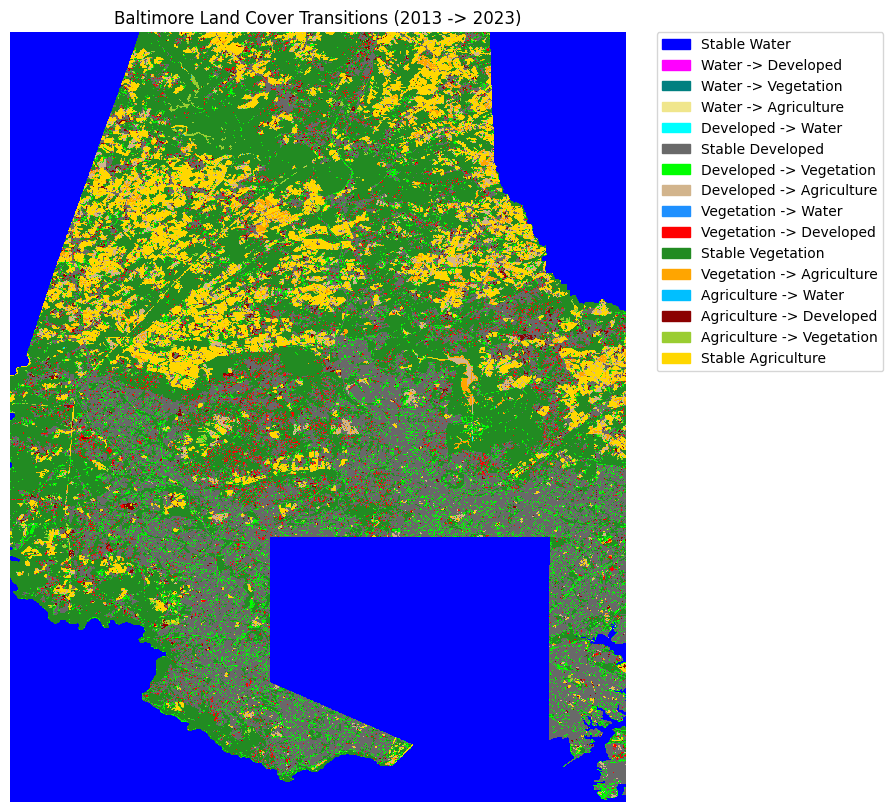

In [6]:


# 1. Define the transitions based on your LULC indices
# Indices: 1=Water, 2=Developed, 3=Forest, 4=Ag
# Change logic: (T1 * 10) + T2
transition_defs = {
    # --- STABLE CLASSES ---
    0:  ("Stable Water", "blue"),                 # 0 -> 0
    11: ("Stable Developed", "dimgrey"),          # 1 -> 1
    22: ("Stable Vegetation", "forestgreen"),     # 2 -> 2
    33: ("Stable Agriculture", "gold"),           # 3 -> 3

    # --- URBANIZATION / DEVELOPMENT ---
    21: ("Vegetation -> Developed", "red"),       # Deforestation/Urbanization
    31: ("Agriculture -> Developed", "darkred"),  # Urbanization
    1:  ("Water -> Developed", "magenta"),        # 0 -> 1 (Reclamation)

    # --- AGRICULTURAL EXPANSION ---
    23: ("Vegetation -> Agriculture", "orange"),  # Clearing for farming
    13: ("Developed -> Agriculture", "tan"),      # Rare
    3:  ("Water -> Agriculture", "khaki"),        # 0 -> 3

    # --- VEGETATION REGROWTH / GREENING ---
    12: ("Developed -> Vegetation", "lime"),      # Reforestation/Greening
    32: ("Agriculture -> Vegetation", "yellowgreen"), # Land abandonment
    2:  ("Water -> Vegetation", "teal"),          # 0 -> 2 (Wetland succession)

    # --- INUNDATION / FLOODING ---
    10: ("Developed -> Water", "cyan"),
    20: ("Vegetation -> Water", "dodgerblue"),
    30: ("Agriculture -> Water", "deepskyblue")
}

# 2. Setup colors and boundaries
# We need to create a map that explicitly links the code (e.g. 32) to a color
vals = sorted(transition_defs.keys())
colors = [transition_defs[v][1] for v in vals]
labels = [transition_defs[v][0] for v in vals]

custom_cmap = ListedColormap(colors)
# Create boundaries that "wrap" around your specific values
# This ensures that value 22 gets color 0, value 23 gets color 1, etc.
norm = BoundaryNorm(vals + [max(vals)+1], custom_cmap.N)

# 3. Plotting
plt.figure(figsize=(12, 10))

# Use the norm to prevent color bleeding/shifting
im = plt.imshow(
    change_map_small.squeeze(),
    cmap=custom_cmap,
    norm=norm,
    interpolation='nearest'
)

# 4. Add a custom legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title("Baltimore Land Cover Transitions (2013 -> 2023)")
plt.axis('off')
plt.show()

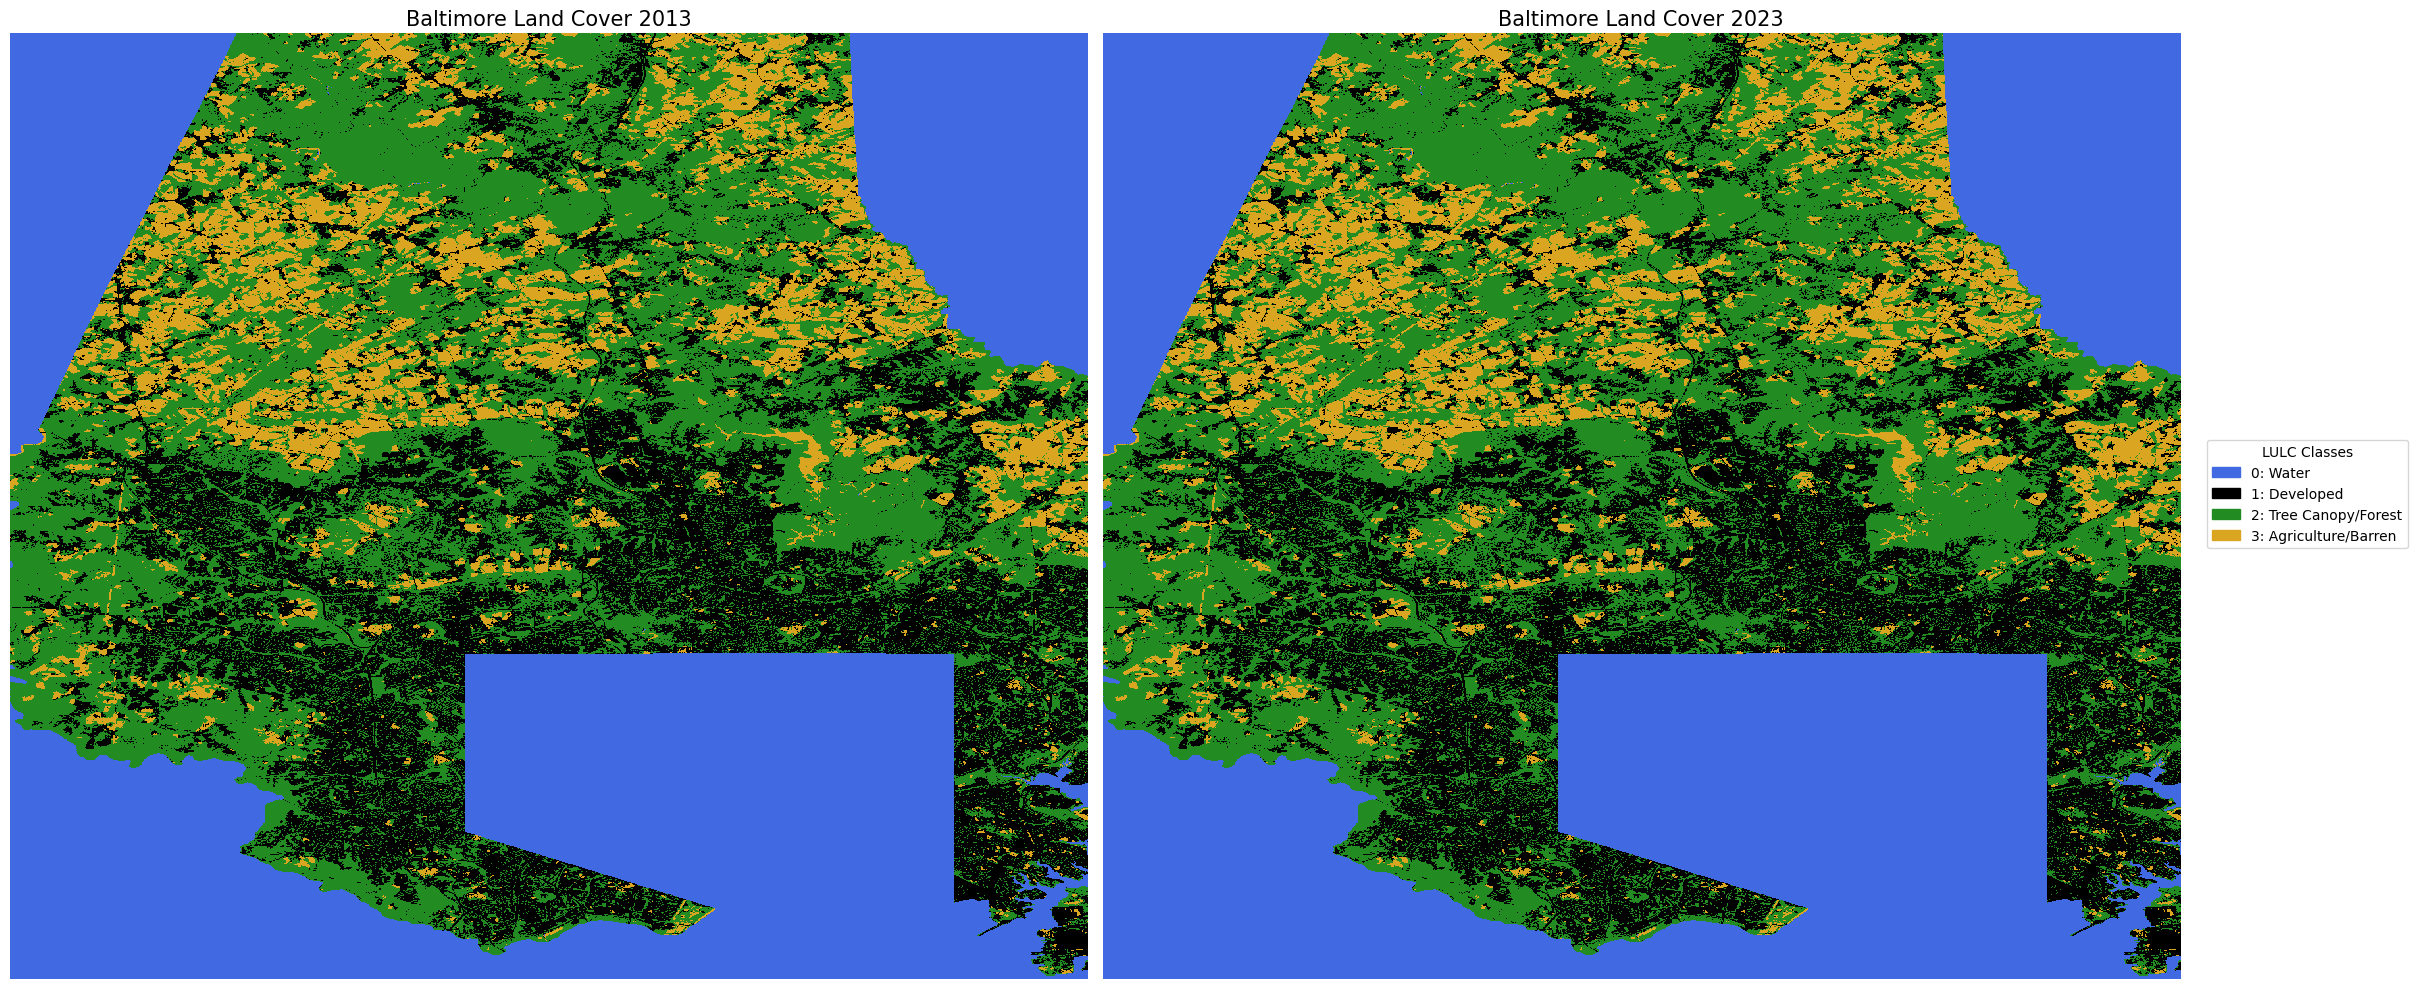

In [18]:

# 1. Define your Land Cover Key (Aligning with your 0-4 indices)
# It's best to have 0 as Background/Unlabeled so it doesn't overlap with real data
land_cover_key = {
    0: ("Water", "royalblue"),
    1: ("Developed", "black"),
    2: ("Tree Canopy/Forest", "forestgreen"),
    3: ("Agriculture/Barren", "goldenrod"),
}

# Extract colors and labels
num_classes = len(land_cover_key)
colors = [land_cover_key[i][1] for i in range(num_classes)]
labels = [land_cover_key[i][0] for i in range(num_classes)]
custom_cmap = ListedColormap(colors)

# CRITICAL: Define boundaries so integers map exactly to colors
# This prevents "Blue" from stretching across multiple class IDs
bounds = list(range(num_classes + 1)) # [0, 1, 2, 3, 4, 5]
norm = BoundaryNorm(bounds, custom_cmap.N)

# 2. Load the combined TIFFs
pred_2013 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif", chunks=True).squeeze()
pred_2023 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif", chunks=True).squeeze()

# Downsample for visualization speed
# Using 'nearest' resampling is vital for categorical data (land cover)
pred_2013_ds = pred_2013.rio.reproject(pred_2013.rio.crs,
                                       shape=(pred_2013.rio.height // 10, pred_2013.rio.width // 10),
                                       resampling=0) # 0 = nearest
pred_2023_ds = pred_2023.rio.reproject(pred_2023.rio.crs,
                                       shape=(pred_2023.rio.height // 10, pred_2023.rio.width // 10),
                                       resampling=0)

# 3. Create the Side-by-Side Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Plot 2013 - Use 'norm' and remove vmin/vmax
pred_2013_ds.plot.imshow(ax=ax1, cmap=custom_cmap, norm=norm, add_colorbar=False, interpolation='nearest')
ax1.set_title("Baltimore Land Cover 2013", fontsize=15)
ax1.axis('off')

# Plot 2023
pred_2023_ds.plot.imshow(ax=ax2, cmap=custom_cmap, norm=norm, add_colorbar=False, interpolation='nearest')
ax2.set_title("Baltimore Land Cover 2023", fontsize=15)
ax2.axis('off')

# 4. Add the Custom Legend
legend_patches = [mpatches.Patch(color=colors[i], label=f"{i}: {labels[i]}") for i in range(num_classes)]
fig.legend(handles=legend_patches, loc='center right', bbox_to_anchor=(1.1, 0.5), title="LULC Classes")

plt.tight_layout()
plt.show()

Calculate Change Map and Statistics for Chesapeake Conservancy LULC

In [12]:
# Load both combined tiffs
real_t1 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_lulc_2013_clipped.tif").squeeze()
real_t2 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_lulc_2023_clipped.tif").squeeze()

# Force pred_t2 to match the exact grid of pred_t1
real_t2 = real_t2.rio.reproject_match(real_t1)

# Create a transition raster
# New value = (Time1 * 10) + Time2
change_map = (real_t1 * 10) + real_t2

# Now you can filter for specific transitions
# Let's find "Deforestation" (Forest [3] -> Developed [1])

# Save the result to your Drive
change_map.rio.to_raster("land_cover_transitions_LULC.tif")

In [13]:
# Load and immediately downsample by a factor of 5
# This turns a 10000x10000 image into 2000x2000
real_t1_small = real_t1.rio.reproject(real_t1.rio.crs, shape=(real_t1.rio.height // 10, real_t1.rio.width // 10))
real_t2_small = real_t2.rio.reproject(real_t2.rio.crs, shape=(real_t2.rio.height // 10, real_t2.rio.width // 10))

change_map_small = (real_t1_small * 10) + real_t2_small
# Now plot change_map_small

In [14]:

geojson_path = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"
change_map = change_map.rio.reproject("EPSG:32618")
# 1. Load your GeoJSON
regions = gpd.read_file(geojson_path)

# 2. CRITICAL: Ensure the GeoJSON and the Raster share the exact same CRS
regions = regions.to_crs(change_map.rio.crs)

# 3. Separate the urban and rural geometries based on LAND_TYPE
urban_geoms = regions[regions['LAND_TYPE'] == 0].geometry
rural_geoms = regions[regions['LAND_TYPE'] == 1].geometry

# 4. Helper function to clip and count pixels
def count_transitions(raster, geoms, transition_codes):
    if geoms.empty:
        return {code: 0 for code in transition_codes}

    # Clip the raster to the geometries. drop=True removes extra empty space.
    clipped_raster = raster.rio.clip(geoms, raster.rio.crs, drop=True)

    counts = {}
    for code in transition_codes:
        # Sum up the pixels matching the specific code
        pixel_count = int((clipped_raster == code).sum().item())
        counts[code] = pixel_count

    return counts

# 5. Run the calculations
codes = [21, 23] # 21: Veg->Dev, 23: Veg->Ag
urban_stats = count_transitions(change_map, urban_geoms, codes)
rural_stats = count_transitions(change_map, rural_geoms, codes)

# Get the resolution from the raster (x_res, y_res)
x_res, y_res = change_map.rio.resolution()
pixel_area = abs(x_res * y_res) # Area of a single pixel in square CRS units (likely sq meters)

total_21 = urban_stats[21] + rural_stats[21]
total_23 = urban_stats[23] + rural_stats[23]
total_deforestation = total_21 + total_23

# 7. Print the Results
print("--- PIXEL DIMENSIONS ---")
print(f"Pixel Resolution: {abs(x_res)} x {abs(y_res)} units")
print(f"Area of 1 pixel: {pixel_area} square units\n")

print("--- URBAN DEFORESTATION (LAND_TYPE 0) ---")
print(f"Veg to Dev (21): {urban_stats[21]} pixels | {urban_stats[21] * pixel_area:,.2f} sq units")
print(f"Veg to Ag (23):  {urban_stats[23]} pixels | {urban_stats[23] * pixel_area:,.2f} sq units")
print(f"Urban Total Area: {(urban_stats[21] + urban_stats[23]) * pixel_area:,.2f} sq units\n")

print("--- RURAL DEFORESTATION (LAND_TYPE 1) ---")
print(f"Veg to Dev (21): {rural_stats[21]} pixels | {rural_stats[21] * pixel_area:,.2f} sq units")
print(f"Veg to Ag (23):  {rural_stats[23]} pixels | {rural_stats[23] * pixel_area:,.2f} sq units")
print(f"Rural Total Area: {(rural_stats[21] + rural_stats[23]) * pixel_area:,.2f} sq units\n")

print("-" * 45)
print("--- OVERALL DEFORESTATION TOTALS ---")
print(f"TOTAL Veg to Dev (21): {total_21} pixels | {total_21 * pixel_area:,.2f} sq units")
print(f"TOTAL Veg to Ag (23):  {total_23} pixels | {total_23 * pixel_area:,.2f} sq units")
print(f"GRAND TOTAL AREA:      {total_deforestation * pixel_area:,.2f} sq units")

--- PIXEL DIMENSIONS ---
Pixel Resolution: 2.4902744211502483 x 2.4902744211502483 units
Area of 1 pixel: 6.201466692635204 square units

--- URBAN DEFORESTATION (LAND_TYPE 0) ---
Veg to Dev (21): 544405 pixels | 3,376,109.47 sq units
Veg to Ag (23):  701 pixels | 4,347.23 sq units
Urban Total Area: 3,380,456.70 sq units

--- RURAL DEFORESTATION (LAND_TYPE 1) ---
Veg to Dev (21): 477696 pixels | 2,962,415.83 sq units
Veg to Ag (23):  65409 pixels | 405,631.73 sq units
Rural Total Area: 3,368,047.57 sq units

---------------------------------------------
--- OVERALL DEFORESTATION TOTALS ---
TOTAL Veg to Dev (21): 1022101 pixels | 6,338,525.31 sq units
TOTAL Veg to Ag (23):  66110 pixels | 409,978.96 sq units
GRAND TOTAL AREA:      6,748,504.27 sq units


In [15]:
# 1. Calculate the total size of the regions directly from the GeoDataFrame
# Because our CRS is in meters (EPSG:32618), this natively returns square meters
total_urban_area_sqm = urban_geoms.area.sum()
total_rural_area_sqm = rural_geoms.area.sum()

# 2. Calculate the deforestation area in square meters for each zone
urban_deforest_sqm = (urban_stats[23]) * pixel_area
rural_deforest_sqm = (rural_stats[23]) * pixel_area

# 3. Calculate the relative percentages
urban_deforest_percent = (urban_deforest_sqm / total_urban_area_sqm) * 100 if total_urban_area_sqm > 0 else 0
rural_deforest_percent = (rural_deforest_sqm / total_rural_area_sqm) * 100 if total_rural_area_sqm > 0 else 0



# 4. Print the relative metrics
print("\n--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---")
print(f"Urban Region Total Size: {total_urban_area_sqm / 10000:,.2f} hectares")
print(f"Urban Deforestation to Agricultural:     {urban_deforest_percent:.3f}% of urban area lost\n")

print(f"Rural Region Total Size: {total_rural_area_sqm / 10000:,.2f} hectares")
print(f"Rural Deforestation Agricultural:     {rural_deforest_percent:.3f}% of rural area lost")

# 2. Calculate the deforestation area in square meters for each zone
urban_deforest_sqm = (urban_stats[21]) * pixel_area
rural_deforest_sqm = (rural_stats[21]) * pixel_area

# 3. Calculate the relative percentages
urban_deforest_percent = (urban_deforest_sqm / total_urban_area_sqm) * 100 if total_urban_area_sqm > 0 else 0
rural_deforest_percent = (rural_deforest_sqm / total_rural_area_sqm) * 100 if total_rural_area_sqm > 0 else 0



# 4. Print the relative metrics
print("\n--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---")
print(f"Urban Region Total Size: {total_urban_area_sqm / 10000:,.2f} hectares")
print(f"Urban Deforestation to Developed:     {urban_deforest_percent:.3f}% of urban area lost\n")

print(f"Rural Region Total Size: {total_rural_area_sqm / 10000:,.2f} hectares")
print(f"Rural Deforestation to Developed:     {rural_deforest_percent:.3f}% of rural area lost")


--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---
Urban Region Total Size: 52,836.04 hectares
Urban Deforestation to Agricultural:     0.001% of urban area lost

Rural Region Total Size: 104,613.05 hectares
Rural Deforestation Agricultural:     0.039% of rural area lost

--- RELATIVE DEFORESTATION (PERCENTAGE OF REGION) ---
Urban Region Total Size: 52,836.04 hectares
Urban Deforestation to Developed:     0.639% of urban area lost

Rural Region Total Size: 104,613.05 hectares
Rural Deforestation to Developed:     0.283% of rural area lost


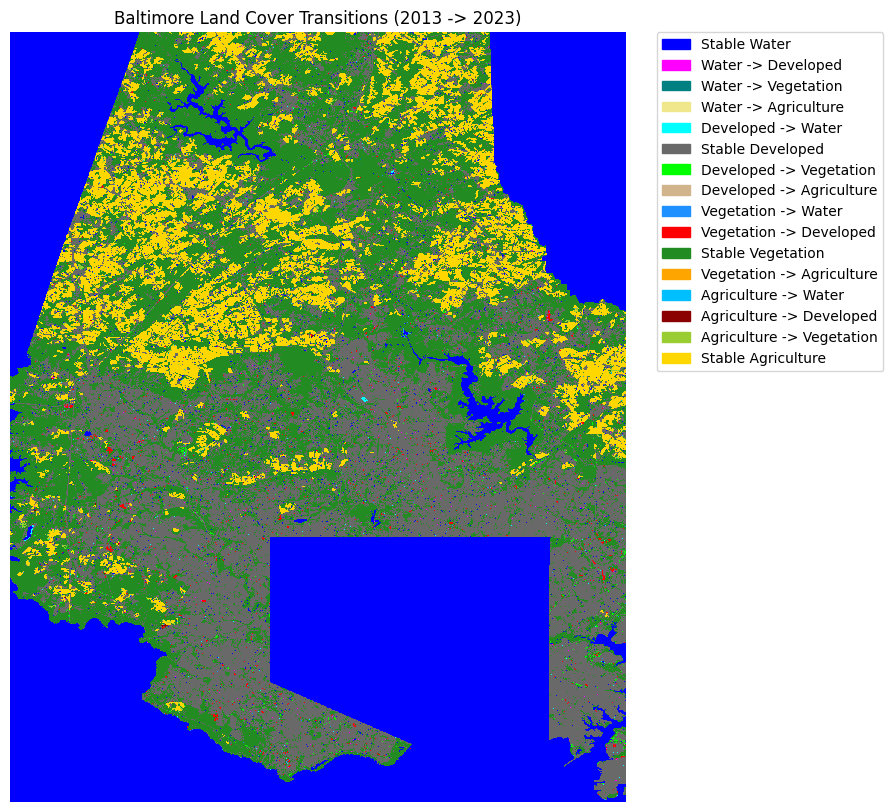

In [16]:


# 1. Define the transitions based on your LULC indices
# Indices: 1=Water, 2=Developed, 3=Forest, 4=Ag
# Change logic: (T1 * 10) + T2
transition_defs = {
    # --- STABLE CLASSES ---
    0:  ("Stable Water", "blue"),                 # 0 -> 0
    11: ("Stable Developed", "dimgrey"),          # 1 -> 1
    22: ("Stable Vegetation", "forestgreen"),     # 2 -> 2
    33: ("Stable Agriculture", "gold"),           # 3 -> 3

    # --- URBANIZATION / DEVELOPMENT ---
    21: ("Vegetation -> Developed", "red"),       # Deforestation/Urbanization
    31: ("Agriculture -> Developed", "darkred"),  # Urbanization
    1:  ("Water -> Developed", "magenta"),        # 0 -> 1 (Reclamation)

    # --- AGRICULTURAL EXPANSION ---
    23: ("Vegetation -> Agriculture", "orange"),  # Clearing for farming
    13: ("Developed -> Agriculture", "tan"),      # Rare
    3:  ("Water -> Agriculture", "khaki"),        # 0 -> 3

    # --- VEGETATION REGROWTH / GREENING ---
    12: ("Developed -> Vegetation", "lime"),      # Reforestation/Greening
    32: ("Agriculture -> Vegetation", "yellowgreen"), # Land abandonment
    2:  ("Water -> Vegetation", "teal"),          # 0 -> 2 (Wetland succession)

    # --- INUNDATION / FLOODING ---
    10: ("Developed -> Water", "cyan"),
    20: ("Vegetation -> Water", "dodgerblue"),
    30: ("Agriculture -> Water", "deepskyblue")
}

# 2. Setup colors and boundaries
# We need to create a map that explicitly links the code (e.g. 32) to a color
vals = sorted(transition_defs.keys())
colors = [transition_defs[v][1] for v in vals]
labels = [transition_defs[v][0] for v in vals]

custom_cmap = ListedColormap(colors)
# Create boundaries that "wrap" around your specific values
# This ensures that value 22 gets color 0, value 23 gets color 1, etc.
norm = BoundaryNorm(vals + [max(vals)+1], custom_cmap.N)

# 3. Plotting
plt.figure(figsize=(12, 10))

# Use the norm to prevent color bleeding/shifting
im = plt.imshow(
    change_map_small.squeeze(),
    cmap=custom_cmap,
    norm=norm,
    interpolation='nearest'
)

# 4. Add a custom legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title("Baltimore Land Cover Transitions (2013 -> 2023)")
plt.axis('off')
plt.show()

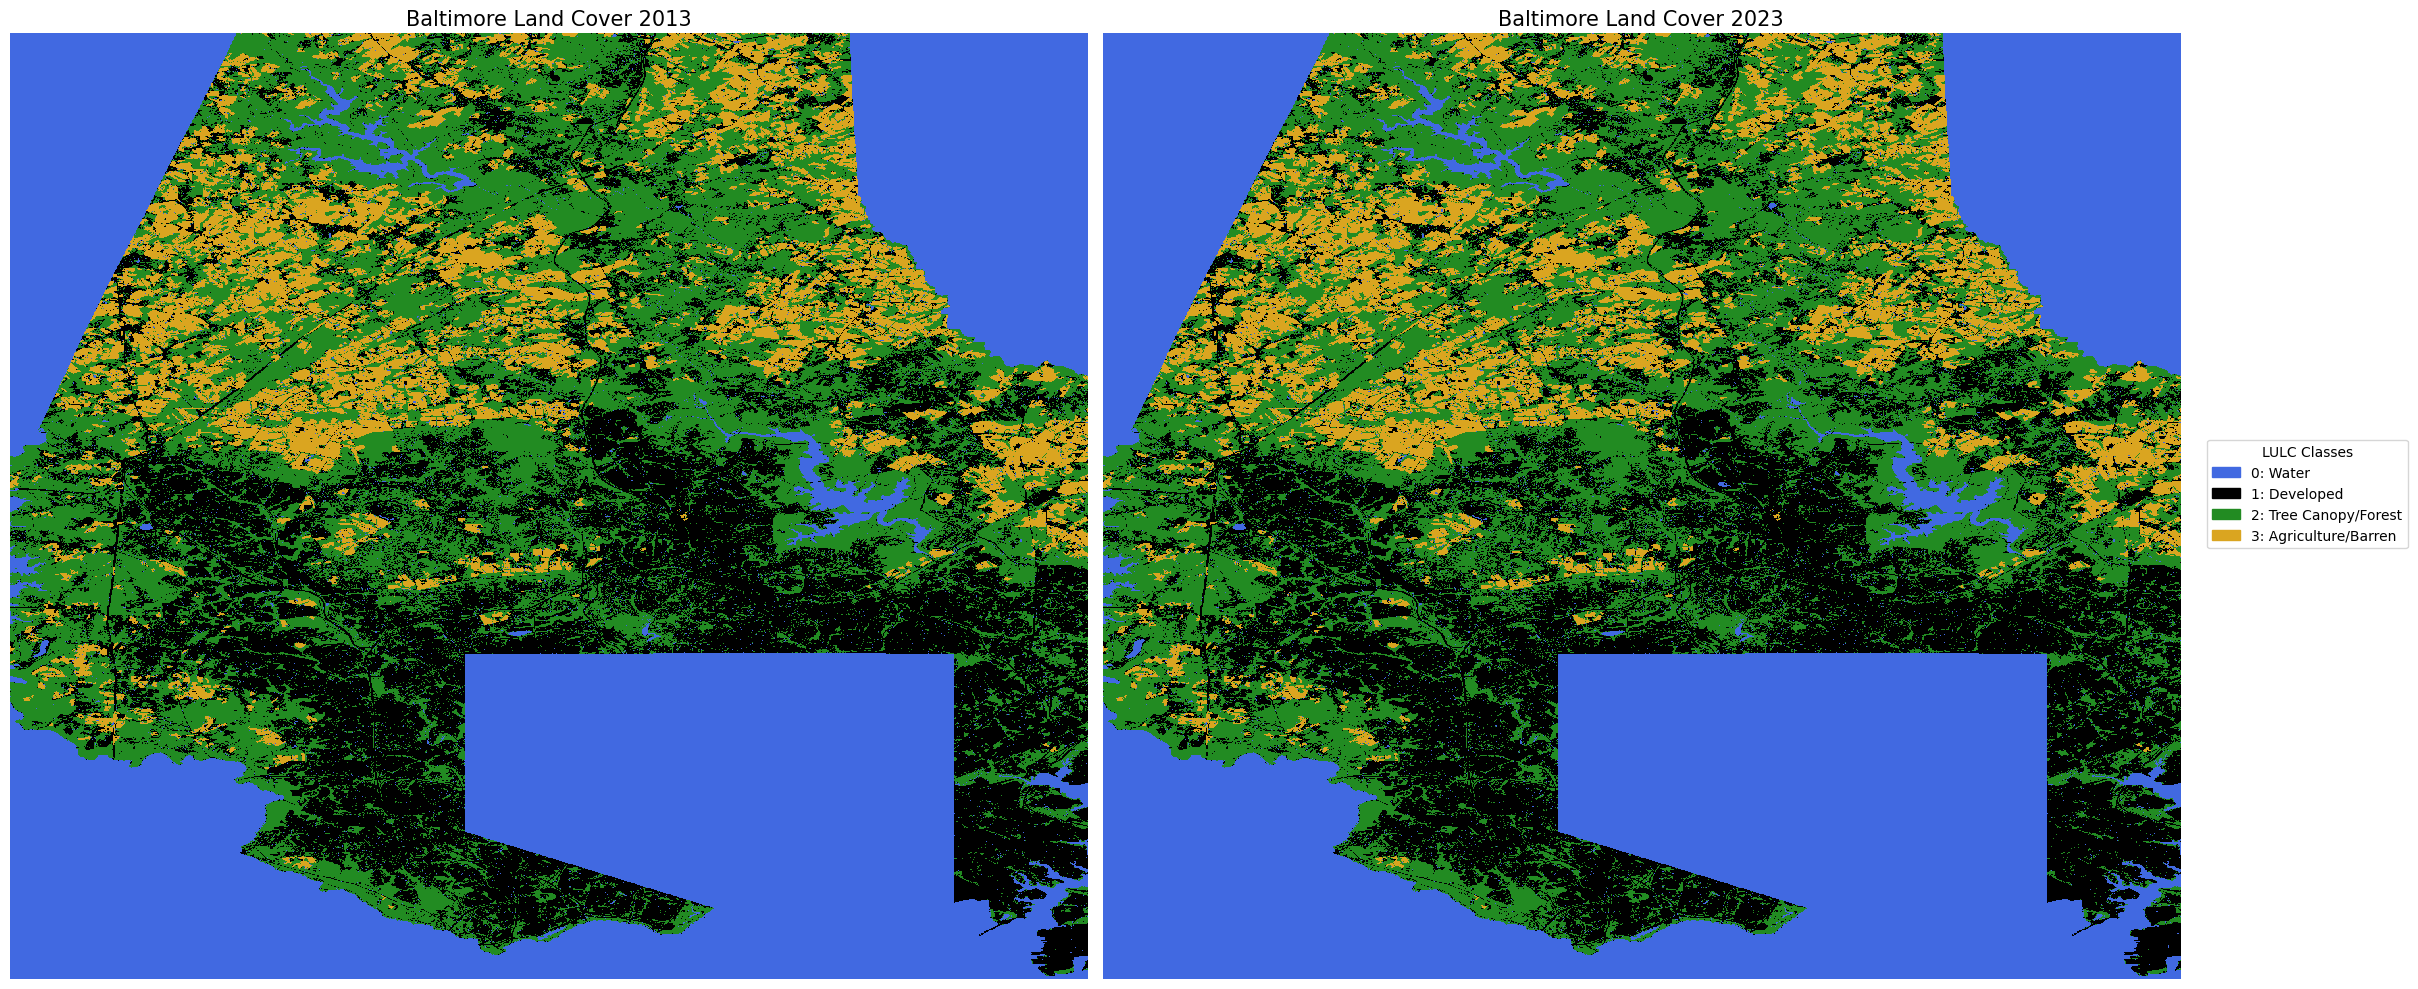

In [17]:

# 1. Define your Land Cover Key (Aligning with your 0-4 indices)
# It's best to have 0 as Background/Unlabeled so it doesn't overlap with real data
land_cover_key = {
    0: ("Water", "royalblue"),
    1: ("Developed", "black"),
    2: ("Tree Canopy/Forest", "forestgreen"),
    3: ("Agriculture/Barren", "goldenrod"),
}

# Extract colors and labels
num_classes = len(land_cover_key)
colors = [land_cover_key[i][1] for i in range(num_classes)]
labels = [land_cover_key[i][0] for i in range(num_classes)]
custom_cmap = ListedColormap(colors)

# CRITICAL: Define boundaries so integers map exactly to colors
# This prevents "Blue" from stretching across multiple class IDs
bounds = list(range(num_classes + 1)) # [0, 1, 2, 3, 4, 5]
norm = BoundaryNorm(bounds, custom_cmap.N)

# 2. Load the combined TIFFs

# Downsample for visualization speed
# Using 'nearest' resampling is vital for categorical data (land cover)
# real_2013_ds = real_2013.rio.reproject(real_2013.rio.crs,
#                                        shape=(real_2013.rio.height // 10, real_2013.rio.width // 10),
#                                        resampling=0) # 0 = nearest
# real_2023_ds = real_2023.rio.reproject(real_2023.rio.crs,
#                                        shape=(real_2023.rio.height // 10, real_2023.rio.width // 10),
#                                        resampling=0)

# 3. Create the Side-by-Side Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Plot 2013 - Use 'norm' and remove vmin/vmax
real_t1_small.plot.imshow(ax=ax1, cmap=custom_cmap, norm=norm, add_colorbar=False, interpolation='nearest')
ax1.set_title("Baltimore Land Cover 2013", fontsize=15)
ax1.axis('off')

# Plot 2023
real_t2_small.plot.imshow(ax=ax2, cmap=custom_cmap, norm=norm, add_colorbar=False, interpolation='nearest')
ax2.set_title("Baltimore Land Cover 2023", fontsize=15)
ax2.axis('off')

# 4. Add the Custom Legend
legend_patches = [mpatches.Patch(color=colors[i], label=f"{i}: {labels[i]}") for i in range(num_classes)]
fig.legend(handles=legend_patches, loc='center right', bbox_to_anchor=(1.1, 0.5), title="LULC Classes")

plt.tight_layout()
plt.show()

Calculate the accuracy of AI model compared to chesapeake conservancy

In [1]:


# 1. Load the two TIFFs
# (e.g., your ground truth and your model's prediction)
tif1_path = "/content/drive/MyDrive/predicted_county/baltimore_full_lulc_2023_clipped.tif"
tif2_path = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif"

raster1 = rioxarray.open_rasterio(tif1_path).squeeze()
raster2 = rioxarray.open_rasterio(tif2_path).squeeze()

# 2. CRITICAL: Force Raster 2 to perfectly match Raster 1's grid/extent
# If they are off by even half a pixel, your similarity score will be wrong.
raster2_matched = raster2.rio.reproject_match(raster1)

# 3. Convert both rasters to 1D arrays (flatten them)
# We use .values to get the raw numpy array out of the xarray object
arr1 = raster1.values.flatten()
arr2 = raster2_matched.values.flatten()

# OPTIONAL: Filter out "NoData" values if your rasters have them (e.g., -9999 or 255)
# nodata_val = 255
# valid_pixels = (arr1 != nodata_val) & (arr2 != nodata_val)
# arr1 = arr1[valid_pixels]
# arr2 = arr2[valid_pixels]

# 4. Calculate Similarity Metrics
# Overall Accuracy: What percentage of pixels are exactly the same?
accuracy = accuracy_score(arr1, arr2)

# Cohen's Kappa: A more robust metric for imbalanced classes (Score from -1 to 1)
# > 0.8 is Excellent, 0.6-0.8 is Good, 0.4-0.6 is Moderate
kappa = cohen_kappa_score(arr1, arr2)

# Confusion Matrix: Shows exactly which classes are being confused with each other
conf_matrix = confusion_matrix(arr1, arr2)

# 5. Print Results
print("--- RASTER SIMILARITY RESULTS 2023---")
print(f"Total Pixels Compared: {len(arr1):,}")
print(f"Overall Accuracy:      {accuracy * 100:.2f}%")
print(f"Cohen's Kappa Score:   {kappa:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

--- RASTER SIMILARITY RESULTS 2023---
Total Pixels Compared: 335,544,320
Overall Accuracy:      87.82%
Cohen's Kappa Score:   0.8307

Confusion Matrix:
[[112262267   1169263   3965986   1059350]
 [      355  64076913  15159154   3948672]
 [      921   7585969  87271468   2501258]
 [      181   2263254   3207138  31072171]]


In [2]:


# 1. Load the two TIFFs
# (e.g., your ground truth and your model's prediction)
tif1_path = "/content/drive/MyDrive/predicted_county/baltimore_full_lulc_2013_clipped.tif"
tif2_path = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif"

raster1 = rioxarray.open_rasterio(tif1_path).squeeze()
raster2 = rioxarray.open_rasterio(tif2_path).squeeze()

# 2. CRITICAL: Force Raster 2 to perfectly match Raster 1's grid/extent
# If they are off by even half a pixel, your similarity score will be wrong.
raster2_matched = raster2.rio.reproject_match(raster1)

# 3. Convert both rasters to 1D arrays (flatten them)
# We use .values to get the raw numpy array out of the xarray object
arr1 = raster1.values.flatten()
arr2 = raster2_matched.values.flatten()

# OPTIONAL: Filter out "NoData" values if your rasters have them (e.g., -9999 or 255)
# nodata_val = 255
# valid_pixels = (arr1 != nodata_val) & (arr2 != nodata_val)
# arr1 = arr1[valid_pixels]
# arr2 = arr2[valid_pixels]

# 4. Calculate Similarity Metrics
# Overall Accuracy: What percentage of pixels are exactly the same?
accuracy = accuracy_score(arr1, arr2)

# Cohen's Kappa: A more robust metric for imbalanced classes (Score from -1 to 1)
# > 0.8 is Excellent, 0.6-0.8 is Good, 0.4-0.6 is Moderate
kappa = cohen_kappa_score(arr1, arr2)

# Confusion Matrix: Shows exactly which classes are being confused with each other
conf_matrix = confusion_matrix(arr1, arr2)

# 5. Print Results
print("--- RASTER SIMILARITY RESULTS 2013---")
print(f"Total Pixels Compared: {len(arr1):,}")
print(f"Overall Accuracy:      {accuracy * 100:.2f}%")
print(f"Cohen's Kappa Score:   {kappa:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

--- RASTER SIMILARITY RESULTS 2013---
Total Pixels Compared: 335,544,320
Overall Accuracy:      86.36%
Cohen's Kappa Score:   0.8099

Confusion Matrix:
[[112241583   2007627   3563181    627350]
 [        0  69308367   9739588   3557034]
 [        0  12863296  82955866   1671301]
 [        0   7323209   4401762  25284156]]
